In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('../../')
from cdriver.datagen.logmap import gen_logmapdata

%matplotlib widget

In [9]:
respath = "/home/zsiga/Projects/Codes/maco_commondriver/results/final/noise_length/noise_maco_res.csv"

df = pd.read_csv(respath)

df.head()

,Unnamed: 0,r2,L
0,0,0.970668,0.001
1,1,0.909070,0.001
2,2,0.923148,0.001
3,3,0.929325,0.001
4,4,0.867112,0.001


In [12]:
# What's the std of a logistic map?
# get data by generating it

# generate data
params = dict(N=1,  # number of realizations
              n=10_000,  # Length of time series
              rint=(3.8, 4.),  # interval to chose from the value of r parameter
              A0=np.array([[0, 0, 0],
                           [1, 0, 0],
                           [1, 0, 0]]), # basic connection structure
              A=np.array([[1., 0., 0.],
                          [0.3, 1., 0.],
                          [0.4, 0., 1.]])
                          )

dataset, _ = gen_logmapdata(params)
print("The std of the logistic map is: ", np.std(dataset[0], axis=0))
S = np.std(dataset[0], axis=0)[0]

Generating dataset: 100%|██████████| 1/1 [00:00<00:00,  8.19it/s]

The std of the logistic map is:  [0.30236511 0.24905916 0.21735084]


In [13]:
df['s2n'] = df['L'] / S

In [14]:
import seaborn as sns

/tmp/ipykernel_1316817/693960361.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["{:.2f}".format(float(i.get_text())) for i in ax.get_xticklabels()], rotation=45, horizontalalignment='right')


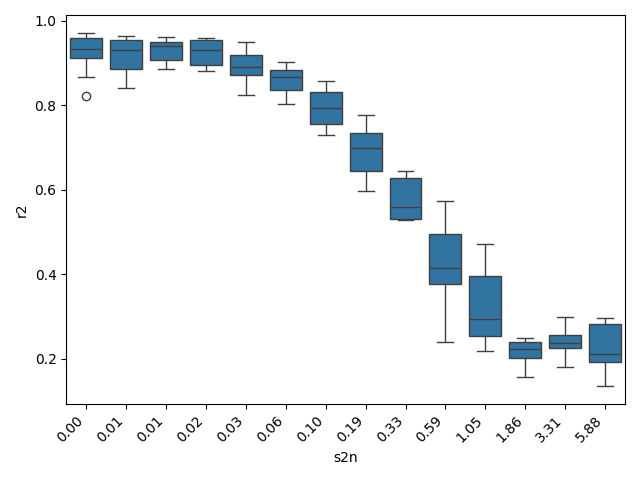

In [30]:
fig, ax = plt.subplots(1, 1)
sns.boxplot(x='s2n', y='r2', data=df)
ax.set_xticklabels(["{:.2f}".format(float(i.get_text())) for i in ax.get_xticklabels()], rotation=45, horizontalalignment='right')
                   
fig.tight_layout()

In [23]:
["{:.2f}".format(i) for i in ax.get_xticklabels()]

TypeError: unsupported format string passed to Text.__format__

In [26]:
b = ax.get_xticklabels()

In [29]:
float(b[0].get_text())

0.003307259865398307